In [1]:
#  DATA MANIPULATION LIBRARIES 
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# ========== DATA VISUALIZATION LIBRARIES ==========
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
# ========== UTILITY LIBRARIES ==========
import os
import warnings
import json
import re

# Suppress common non-critical warnings for a cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Display settings for better DataFrame visualization
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 1000)

In [13]:
# ---------- LOAD DATASETS ----------
# This section loads the WHO COVID-19 daily and weekly datasets,
# previews their structure, and provides basic metadata to orient the analysis.
print(f"Loading datasets - initiated at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load daily and weekly COVID-19 data from WHO
daily_data = pd.read_csv('./Covid Datasets/WHO-COVID-19-global-daily-data.csv')
weekly_data = pd.read_csv('./Covid Datasets/WHO-COVID-19-global-data.csv')

Loading datasets - initiated at 2025-06-13 17:45:32


In [15]:
# DAILY DATASET PREVIEW 
daily_data.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,VC,Saint Vincent and the Grenadines,AMR,NaN,0,NaN,0
1,2020-01-04,SN,Senegal,AFR,NaN,0,NaN,0
2,2020-01-04,SB,Solomon Islands,WPR,0.00,0,0.00,0
3,2020-01-04,LK,Sri Lanka,SEAR,0.00,0,0.00,0
4,2020-01-04,SY,Syrian Arab Republic,EMR,NaN,0,NaN,0


In [17]:
# WEEKLY DATASET PREVIEW
display(weekly_data.head())

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,NaN,0,NaN,0
1,2020-01-12,AF,Afghanistan,EMRO,NaN,0,NaN,0
2,2020-01-19,AF,Afghanistan,EMRO,NaN,0,NaN,0
3,2020-01-26,AF,Afghanistan,EMRO,NaN,0,NaN,0
4,2020-02-02,AF,Afghanistan,EMRO,NaN,0,NaN,0


In [19]:
# ---------- DATASET OVERVIEW ----------
print(f"Daily Dataset: {daily_data.shape[0]:,} rows × {daily_data.shape[1]} columns")
print(f"Weekly Dataset: {weekly_data.shape[0]:,} rows × {weekly_data.shape[1]} columns")

Daily Dataset: 472,560 rows × 8 columns
Weekly Dataset: 67,680 rows × 8 columns


In [21]:
# List columns for reference.
print("\nColumns in both datasets:")
for col in daily_data.columns:
    print(f"- {col}")


Columns in both datasets:
- Date_reported
- Country_code
- Country
- WHO_region
- New_cases
- Cumulative_cases
- New_deaths
- Cumulative_deaths


In [25]:
# Ensure the date column is in datetime format
weekly_data['Date_reported'] = pd.to_datetime(weekly_data['Date_reported'])

# Sort data by country and date (important for time series consistency)
weekly_data = weekly_data.sort_values(['Country', 'Date_reported'])

# Copy the cleaned data for further analysis to preserve the original
covid_weekly = weekly_data.copy()

Analyzing global COVID-19 trends...


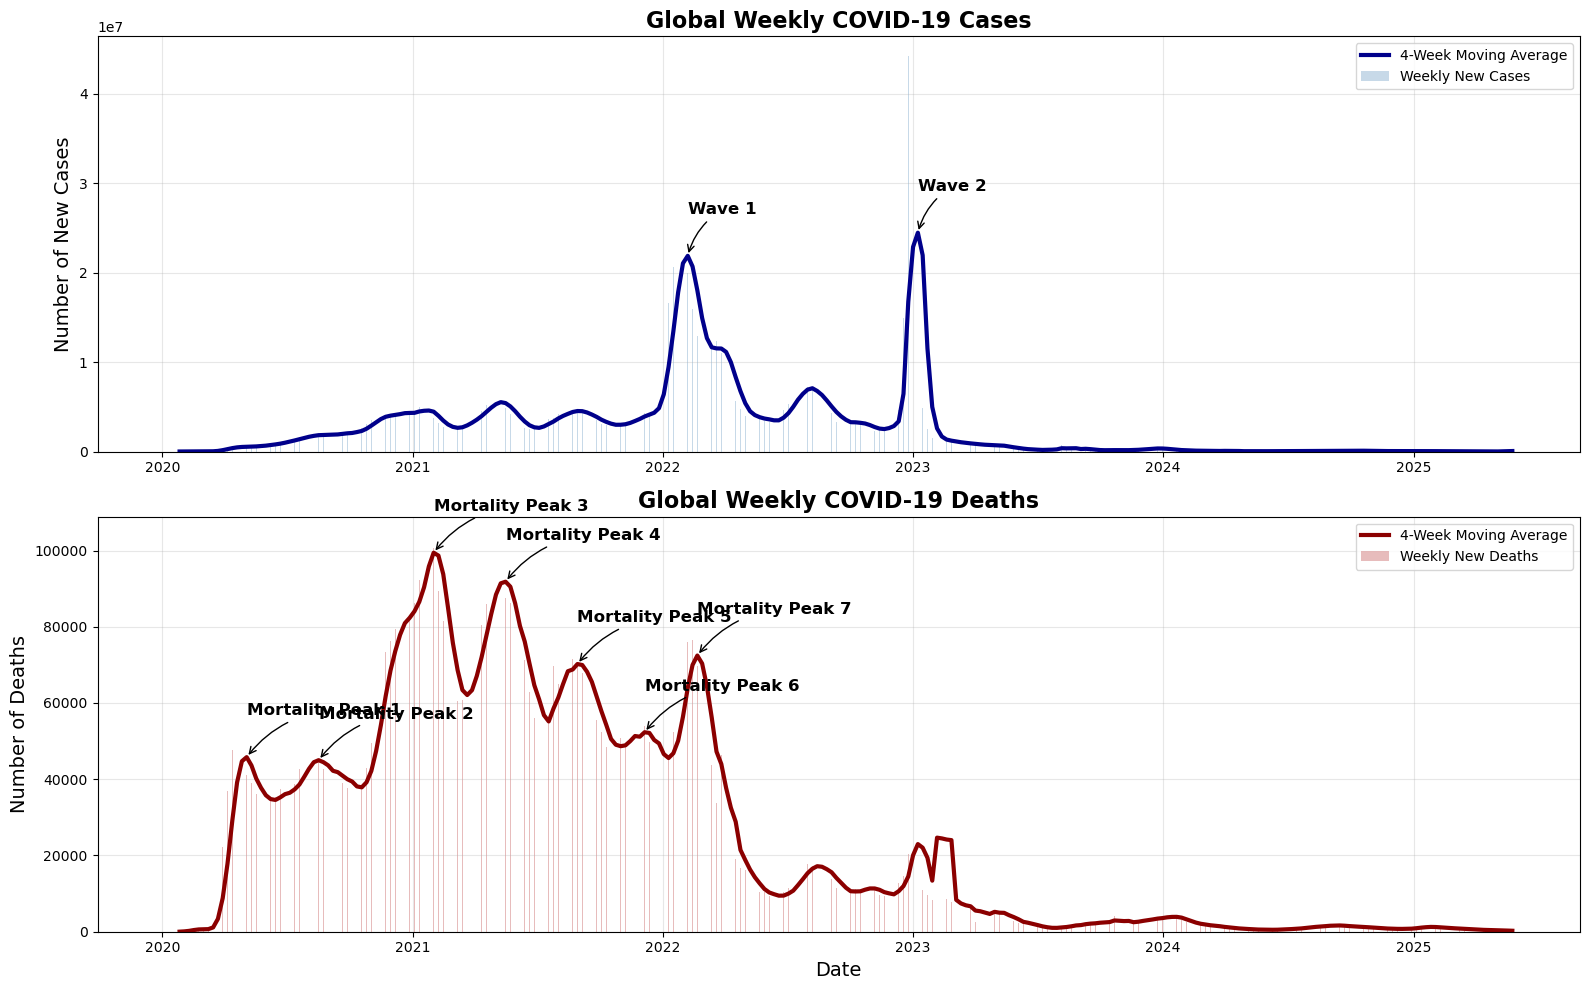

In [27]:
# ---------- GLOBAL TREND ANALYSIS ----------
print("Analyzing global COVID-19 trends...")

# Aggregate global weekly data by summing new cases/deaths and taking maximum cumulative values per week
global_weekly = covid_weekly.groupby('Date_reported').agg(
    New_cases=('New_cases', 'sum'),
    New_deaths=('New_deaths', 'sum'),
    Cumulative_cases=('Cumulative_cases', 'max'),
    Cumulative_deaths=('Cumulative_deaths', 'max')
).reset_index()

# Calculate 4-week moving averages to smooth short-term fluctuations
global_weekly['Cases_MA_4W'] = global_weekly['New_cases'].rolling(window=4).mean()
global_weekly['Deaths_MA_4W'] = global_weekly['New_deaths'].rolling(window=4).mean()

# ---------- GLOBAL TRENDS VISUALIZATION ----------
plt.figure(figsize=(16, 10))

# --- Plot 1: Weekly New Cases with Moving Average and Peaks ---
ax1 = plt.subplot(2, 1, 1)
ax1.bar(
    global_weekly['Date_reported'], global_weekly['New_cases'],
    alpha=0.3, color='steelblue', label='Weekly New Cases'
)
ax1.plot(
    global_weekly['Date_reported'], global_weekly['Cases_MA_4W'],
    color='darkblue', linewidth=3, label='4-Week Moving Average'
)

# Identify and annotate major pandemic waves (peaks in new cases)
from scipy.signal import find_peaks
peaks, _ = find_peaks(
    global_weekly['Cases_MA_4W'],
    height=global_weekly['Cases_MA_4W'].max() * 0.4,
    distance=8
)
for i, peak in enumerate(peaks):
    ax1.annotate(
        f'Wave {i+1}',
        xy=(global_weekly['Date_reported'].iloc[peak], global_weekly['Cases_MA_4W'].iloc[peak]),
        xytext=(0, 30), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black'),
        fontsize=12, fontweight='bold'
    )

ax1.set_title('Global Weekly COVID-19 Cases', fontsize=16, fontweight='bold')
ax1.set_ylabel('Number of New Cases', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Weekly New Deaths with Moving Average and Peaks ---
ax2 = plt.subplot(2, 1, 2)
ax2.bar(
    global_weekly['Date_reported'], global_weekly['New_deaths'],
    alpha=0.3, color='firebrick', label='Weekly New Deaths'
)
ax2.plot(
    global_weekly['Date_reported'], global_weekly['Deaths_MA_4W'],
    color='darkred', linewidth=3, label='4-Week Moving Average'
)

# Identify and annotate major mortality peaks
death_peaks, _ = find_peaks(
    global_weekly['Deaths_MA_4W'],
    height=global_weekly['Deaths_MA_4W'].max() * 0.4,
    distance=8
)
for i, peak in enumerate(death_peaks):
    ax2.annotate(
        f'Mortality Peak {i+1}',
        xy=(global_weekly['Date_reported'].iloc[peak], global_weekly['Deaths_MA_4W'].iloc[peak]),
        xytext=(0, 30), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black'),
        fontsize=12, fontweight='bold'
    )

ax2.set_title('Global Weekly COVID-19 Deaths', fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylabel('Number of Deaths', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
print("\nAnalyzing regional patterns...")

# ---------- REGIONAL DATA AGGREGATION ----------
# Group by region and date to aggregate weekly stats
regional_weekly = covid_weekly.groupby(['WHO_region', 'Date_reported']).agg(
    New_cases=('New_cases', 'sum'),
    New_deaths=('New_deaths', 'sum'),
    Cumulative_cases=('Cumulative_cases', 'max'),
    Cumulative_deaths=('Cumulative_deaths', 'max')
).reset_index()


Analyzing regional patterns...


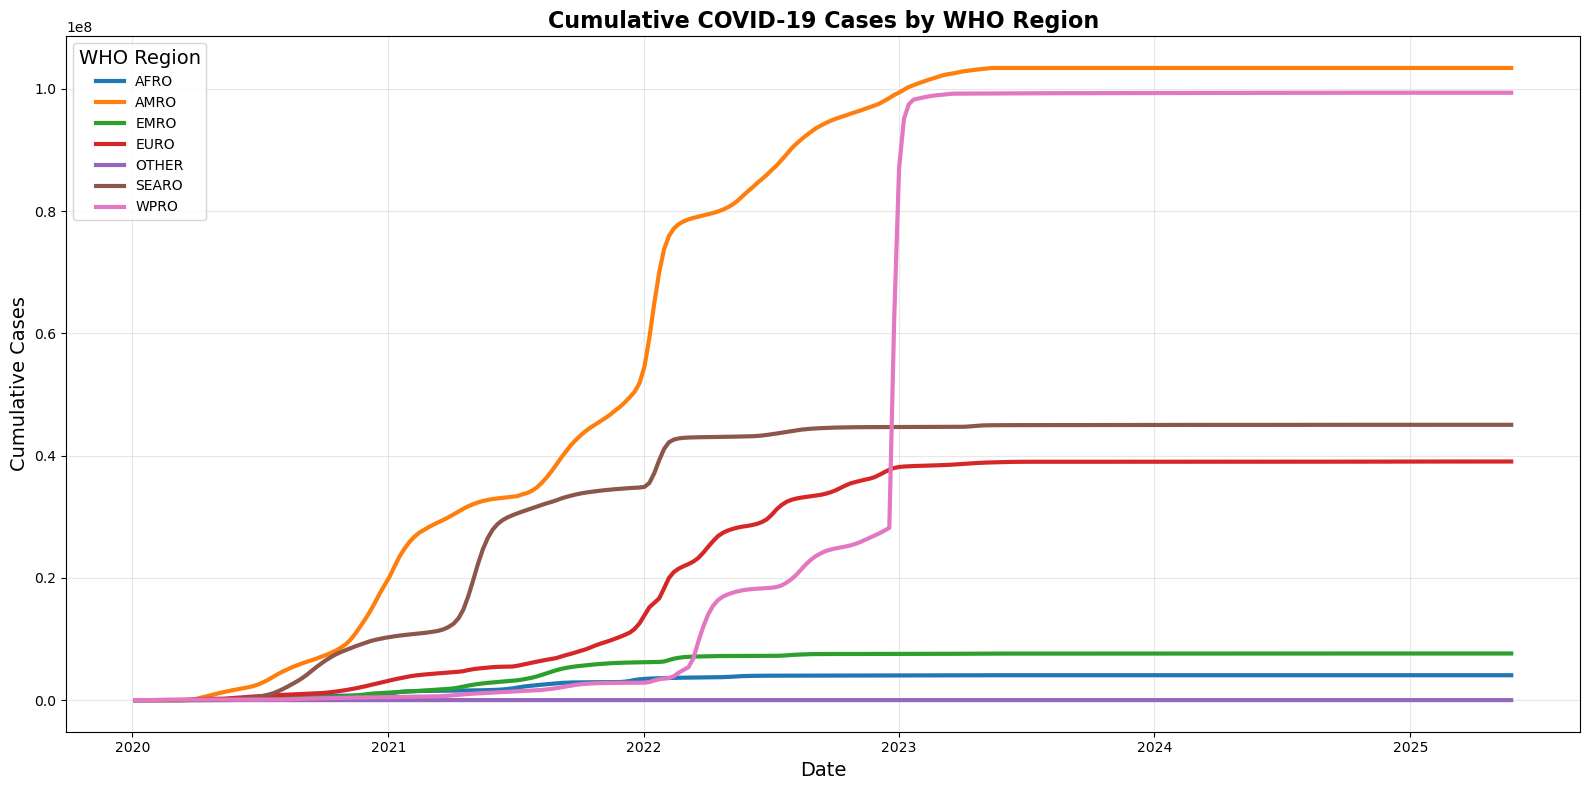

In [33]:
# ---------- LINE PLOT: CUMULATIVE CASES BY REGION ----------
plt.figure(figsize=(16, 8))
for region in regional_weekly['WHO_region'].unique():
    if pd.notnull(region):  # Skip null regions if any
        region_data = regional_weekly[regional_weekly['WHO_region'] == region]
        plt.plot(
            region_data['Date_reported'], region_data['Cumulative_cases'],
            linewidth=3, label=region
        )

plt.title('Cumulative COVID-19 Cases by WHO Region', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Cases', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='WHO Region', title_fontsize=14)
plt.tight_layout()
plt.show()


Analyzing case fatality rates...


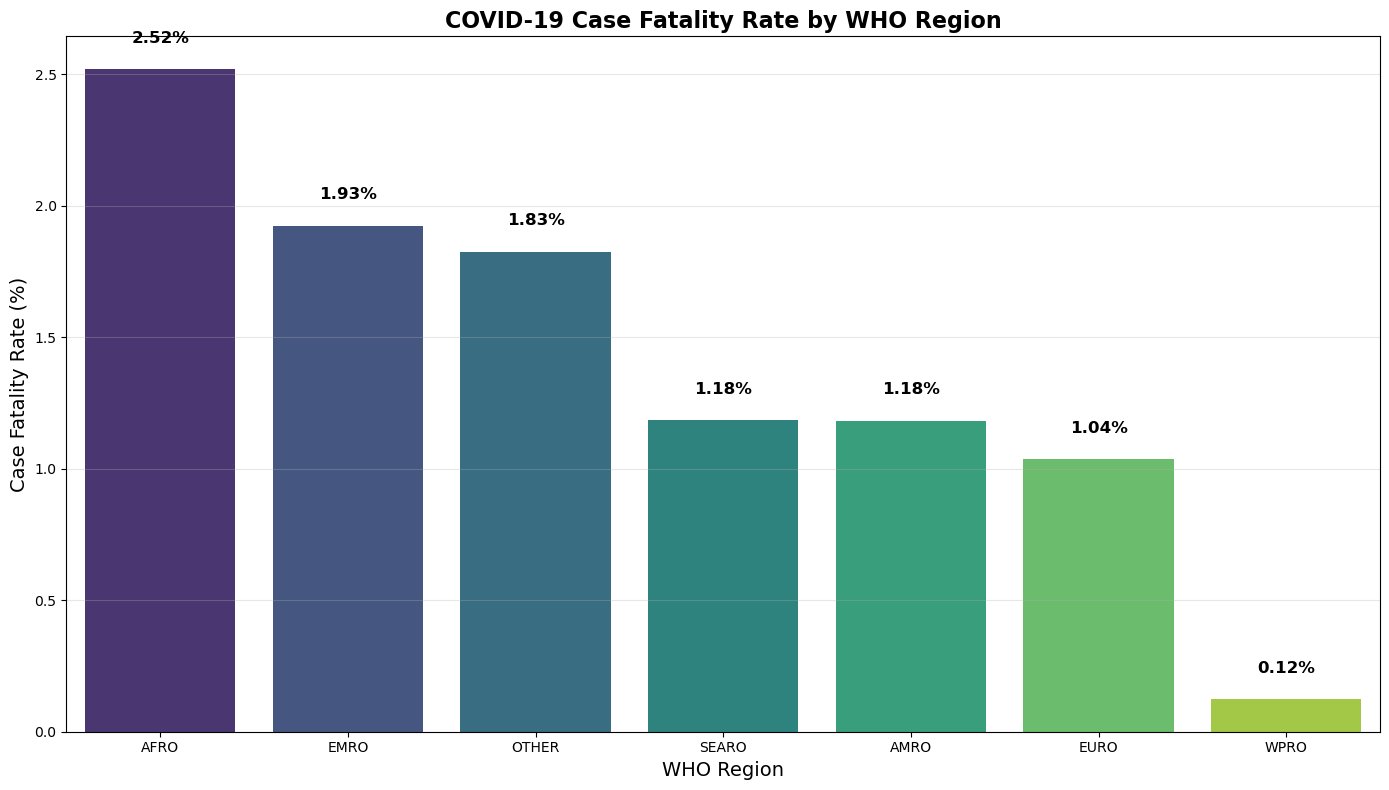

In [35]:
print("\nAnalyzing case fatality rates...")

# ---------- CFR CALCULATION ----------
# Case Fatality Rate (CFR) = (Cumulative Deaths / Cumulative Cases) * 100
regional_weekly['CFR'] = (regional_weekly['Cumulative_deaths'] / regional_weekly['Cumulative_cases']) * 100

# Extract the latest CFR value for each region (most recent date in dataset)
latest_cfr = (
    regional_weekly
    .sort_values(['WHO_region', 'Date_reported'])
    .groupby('WHO_region')
    .tail(1)[['WHO_region', 'CFR']]
    .reset_index(drop=True)
    .sort_values('CFR', ascending=False)
)

# ---------- CFR VISUALIZATION ----------
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x='WHO_region', y='CFR', data=latest_cfr, palette='viridis'
)
plt.title('COVID-19 Case Fatality Rate by WHO Region', fontsize=16, fontweight='bold')
plt.xlabel('WHO Region', fontsize=14)
plt.ylabel('Case Fatality Rate (%)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Annotate bars with CFR values
for i, v in enumerate(latest_cfr['CFR']):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('regional_cfr.png', dpi=300, bbox_inches='tight')
plt.show()